# 08 - Decision Trees

This notebook adds custom CART-style decision trees to EnergyTypeNet. EnergyTypeNet remains the primary dataset; sklearn toy data is used only for clean 2D geometry and California Housing is optional if it is already cached locally.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_moons
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from src.models import DecisionTreeClassifierCustom, DecisionTreeRegressorCustom

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 1. Decision Tree Theory

Decision trees split feature space into rectangular regions. Classification trees choose splits that reduce impurity, commonly Gini impurity or entropy. Regression trees choose splits that reduce variance or mean squared error. The main strengths are interpretability and non-linear decision boundaries; the main risk is overfitting when the tree grows too deep.

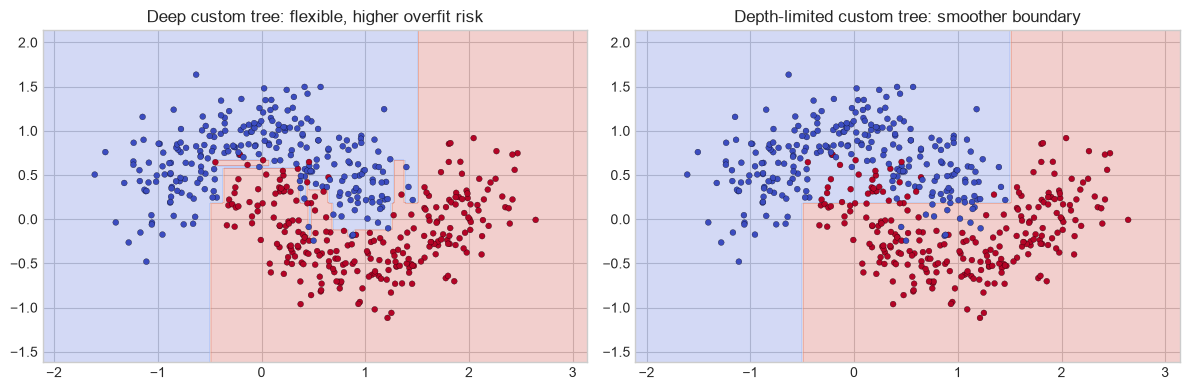

In [2]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.25, random_state=RANDOM_STATE)
tree_full = DecisionTreeClassifierCustom(max_depth=None, min_samples_split=2).fit(X_moons, y_moons)
tree_shallow = DecisionTreeClassifierCustom(max_depth=3, min_samples_split=5).fit(X_moons, y_moons)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=18, cmap='coolwarm', edgecolor='k', linewidth=0.2)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_boundary(axes[0], tree_full, X_moons, y_moons, 'Deep custom tree: flexible, higher overfit risk')
plot_boundary(axes[1], tree_shallow, X_moons, y_moons, 'Depth-limited custom tree: smoother boundary')
plt.tight_layout()

## 2. Custom Classifier on EnergyTypeNet

The primary task predicts building type from the EnergyTypeNet features. A tree can capture threshold rules such as high square footage plus high energy consumption, but depth control is important because the dataset is small.

In [3]:
train_df = pd.read_csv(ROOT / 'data' / 'train_energy_data.csv').dropna()
test_df = pd.read_csv(ROOT / 'data' / 'test_energy_data.csv').dropna()

target = 'Building Type'
feature_cols = ['Energy Consumption', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
label_map = {'Residential': 0, 'Commercial': 1, 'Industrial': 2}

X_train = train_df[feature_cols].to_numpy(float)
y_train = train_df[target].map(label_map).to_numpy()
X_test = test_df[feature_cols].to_numpy(float)
y_test = test_df[target].map(label_map).to_numpy()

custom_clf = DecisionTreeClassifierCustom(max_depth=4, min_samples_split=10, criterion='gini').fit(X_train, y_train)
sklearn_clf = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=RANDOM_STATE).fit(X_train, y_train)

classification_results = pd.DataFrame([
    {
        'model': 'Custom CART classifier',
        'train_accuracy': accuracy_score(y_train, custom_clf.predict(X_train)),
        'test_accuracy': accuracy_score(y_test, custom_clf.predict(X_test)),
        'test_macro_f1': f1_score(y_test, custom_clf.predict(X_test), average='macro'),
    },
    {
        'model': 'sklearn DecisionTreeClassifier',
        'train_accuracy': accuracy_score(y_train, sklearn_clf.predict(X_train)),
        'test_accuracy': accuracy_score(y_test, sklearn_clf.predict(X_test)),
        'test_macro_f1': f1_score(y_test, sklearn_clf.predict(X_test), average='macro'),
    },
])
classification_results

,model,train_accuracy,test_accuracy,test_macro_f1
0,Custom CART classifier,0.631,0.59,0.591503
1,sklearn DecisionTreeClassifier,0.631,0.59,0.591503


,feature,custom_importance,sklearn_importance
0,Energy Consumption,0.648425,0.648425
1,Square Footage,0.251493,0.251493
2,Number of Occupants,0.077384,0.077384
3,Appliances Used,0.022697,0.022697
4,Average Temperature,0.000000,0.000000


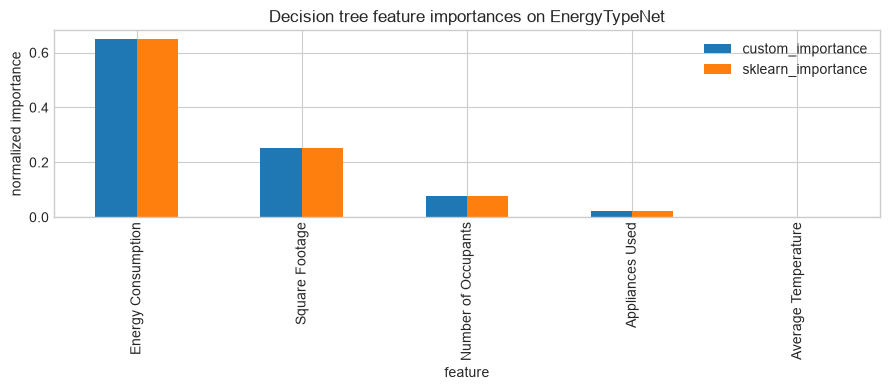

In [4]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'custom_importance': custom_clf.feature_importances_,
    'sklearn_importance': sklearn_clf.feature_importances_,
}).sort_values('custom_importance', ascending=False)

importance_df.plot(x='feature', y=['custom_importance', 'sklearn_importance'], kind='bar', figsize=(9, 4))
plt.title('Decision tree feature importances on EnergyTypeNet')
plt.ylabel('normalized importance')
plt.tight_layout()
importance_df

## 3. Energy Consumption Regression

EnergyTypeNet also supports regression. Here the tree predicts `Energy Consumption` from structural and usage features.

In [5]:
reg_features = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
reg_target = 'Energy Consumption'

Xr_train = train_df[reg_features].to_numpy(float)
yr_train = train_df[reg_target].to_numpy(float)
Xr_test = test_df[reg_features].to_numpy(float)
yr_test = test_df[reg_target].to_numpy(float)

custom_reg = DecisionTreeRegressorCustom(max_depth=5, min_samples_split=10).fit(Xr_train, yr_train)
sklearn_reg = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=RANDOM_STATE).fit(Xr_train, yr_train)

rows = []
for name, model in [('Custom CART regressor', custom_reg), ('sklearn DecisionTreeRegressor', sklearn_reg)]:
    pred_train = model.predict(Xr_train)
    pred_test = model.predict(Xr_test)
    rows.append({
        'model': name,
        'train_rmse': mean_squared_error(yr_train, pred_train) ** 0.5,
        'test_rmse': mean_squared_error(yr_test, pred_test) ** 0.5,
        'test_mae': mean_absolute_error(yr_test, pred_test),
        'test_r2': r2_score(yr_test, pred_test),
    })

regression_results = pd.DataFrame(rows)
regression_results

,model,train_rmse,test_rmse,test_mae,test_r2
0,Custom CART regressor,412.517975,514.92061,449.976711,0.61362
1,sklearn DecisionTreeRegressor,412.517975,514.92061,449.976711,0.61362


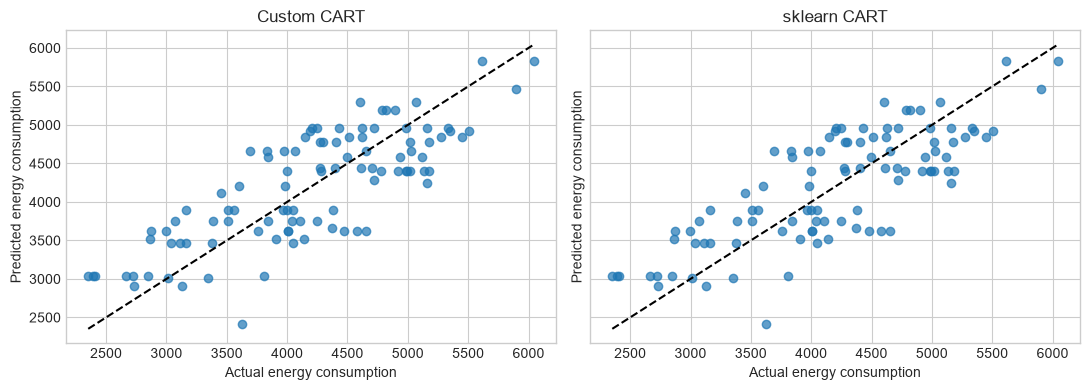

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, [('Custom CART', custom_reg), ('sklearn CART', sklearn_reg)]):
    pred = model.predict(Xr_test)
    ax.scatter(yr_test, pred, alpha=0.7)
    low, high = yr_test.min(), yr_test.max()
    ax.plot([low, high], [low, high], 'k--')
    ax.set_title(name)
    ax.set_xlabel('Actual energy consumption')
    ax.set_ylabel('Predicted energy consumption')
plt.tight_layout()

## 4. Optional California Housing Regression

This section runs only if sklearn's California Housing dataset is already cached locally. It does not download data and it does not add files to the repository.

In [7]:
try:
    housing = fetch_california_housing(download_if_missing=False)
    Xh_train, Xh_test, yh_train, yh_test = train_test_split(
        housing.data, housing.target, test_size=0.25, random_state=RANDOM_STATE
    )
    custom_housing = DecisionTreeRegressorCustom(max_depth=6, min_samples_split=20).fit(Xh_train, yh_train)
    sklearn_housing = DecisionTreeRegressor(max_depth=6, min_samples_split=20, random_state=RANDOM_STATE).fit(Xh_train, yh_train)
    housing_results = pd.DataFrame([
        {'model': 'Custom CART regressor', 'test_r2': r2_score(yh_test, custom_housing.predict(Xh_test)), 'test_mae': mean_absolute_error(yh_test, custom_housing.predict(Xh_test))},
        {'model': 'sklearn DecisionTreeRegressor', 'test_r2': r2_score(yh_test, sklearn_housing.predict(Xh_test)), 'test_mae': mean_absolute_error(yh_test, sklearn_housing.predict(Xh_test))},
    ])
except OSError as exc:
    housing_results = pd.DataFrame([{'model': 'California Housing skipped', 'test_r2': np.nan, 'test_mae': np.nan, 'note': str(exc)}])

housing_results

,model,test_r2,test_mae,note
0,California Housing skipped,NaN,NaN,Data not found and `download_if_missing` is False


## 5. Summary

| Algorithm | Dataset | Task | Custom? | Main Metric | Notes |
| --- | --- | --- | --- | --- | --- |
| DecisionTreeClassifierCustom | EnergyTypeNet | Building type classification | Yes | Accuracy / Macro F1 | CART-style Gini or entropy splits |
| DecisionTreeRegressorCustom | EnergyTypeNet | Energy consumption regression | Yes | RMSE / MAE / R2 | MSE-reduction regression tree |
| sklearn DecisionTreeClassifier | EnergyTypeNet | Building type classification | No | Accuracy / Macro F1 | Reference implementation |
| sklearn DecisionTreeRegressor | EnergyTypeNet | Energy consumption regression | No | RMSE / MAE / R2 | Reference implementation |

Key takeaways:
- The custom classifier and regressor match sklearn closely, which validates the split logic and impurity/reduction calculations.
- Classification accuracy remains around the same ceiling seen in earlier notebooks, confirming that a more flexible tree cannot fully overcome overlapping building classes.
- The regression tree gives a useful non-linear baseline for energy consumption, but its performance is still limited by the small number of available physical building features.
- California Housing is optional and intentionally skipped when the dataset is not cached locally, keeping the notebook reproducible without downloading extra data.
